# Crypto Intraday Strategies — Methodology Top-3

## Overview

This notebook tests **8 strategies** on hourly data for 20 cryptocurrencies.
Methodology identical to the GPW intraday project:
- Each day we rank **all 20 cryptos** by the signal of a given strategy
- We invest equally in the **top-3** (or bottom-3) best candidates
- Entry always at **Open[1]** — first candle after signal confirmation (no lookahead bias)
- Crypto trades **24/7** → "day" = UTC calendar day (00:00–23:59)

## Strategies

**Carried over from the GPW project (adapted for 24/7 crypto):**
1. **First-Hour Momentum** — top 3 by first-hour return; bet on trend continuation
2. **Mean Reversion 1h** — bottom 3 by first-hour return; bet on bounce after large drop
3. **Gap Up** — top 3 by gap vs previous close (threshold 0.5%)
4. **EoD Streak** — top 3 by longest consecutive rising candles

**New — crypto-specific:**
5. **RSI Oversold** — RSI(14) < 30; bet on oversold bounce
6. **Bollinger Bands** — close below lower band; mean-reversion bet
7. **EMA Golden Cross** — EMA(8) crossed above EMA(21) within last 3 candles
8. **MACD + RSI Hybrid** — MACD > signal line AND RSI < 40 simultaneously


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Top-20 cryptocurrencies by market cap (2026)
UNIVERSE = {
    "BTC-USD":   "Bitcoin",
    "ETH-USD":   "Ethereum",
    "BNB-USD":   "BNB",
    "SOL-USD":   "Solana",
    "XRP-USD":   "XRP",
    "ADA-USD":   "Cardano",
    "AVAX-USD":  "Avalanche",
    "DOGE-USD":  "Dogecoin",
    "TRX-USD":   "TRON",
    "DOT-USD":   "Polkadot",
    "LINK-USD":  "Chainlink",
    "MATIC-USD": "Polygon",
    "LTC-USD":   "Litecoin",
    "UNI-USD":   "Uniswap",
    "ATOM-USD":  "Cosmos",
    "XLM-USD":   "Stellar",
    "NEAR-USD":  "NEAR",
    "ICP-USD":   "Internet Computer",
    "FIL-USD":   "Filecoin",
    "ALGO-USD":  "Algorand",
}

INITIAL_CAPITAL = 10_000   # USD
COST_PER_SIDE   = 0.001    # 0.1%
TOP_K           = 3

end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=32)   # extra buffer for indicators

print(f"Universe: {len(UNIVERSE)} kryptowalut")
print(f"Zakres:   {start_dt.date()} -> {end_dt.date()}, interwał 1h")
print()

crypto_frames = {}

for ticker, name in UNIVERSE.items():
    print(f"Pobieram: {name} ({ticker})")
    try:
        df = yf.download(
            ticker,
            start=start_dt.strftime("%Y-%m-%d"),
            end=end_dt.strftime("%Y-%m-%d"),
            interval="1h",
            progress=False,
            auto_adjust=True,
        )
        if df.empty:
            print(f"  Brak danych.")
            continue
        # Flatten MultiIndex if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0] for c in df.columns]
        # Drop timezone info
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)
        df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
        df = df[df["Open"] > 0].dropna()
        if len(df) < 50:
            print(f"  Zbyt mało danych ({len(df)} barek).")
            continue
        crypto_frames[name] = df
    except Exception as e:
        print(f"  Blad: {e}")

print(f"\nZaladowano {len(crypto_frames)}/{len(UNIVERSE)} kryptowalut.")
for n, d in list(crypto_frames.items())[:3]:
    print(f"  {n}: {len(d)} barek, {d.index[0]} -> {d.index[-1]}")


Universe: 20 kryptowalut
Zakres:   2026-02-04 -> 2026-03-08, interwał 1h

Pobieram: Bitcoin (BTC-USD)
Pobieram: Ethereum (ETH-USD)
Pobieram: BNB (BNB-USD)
Pobieram: Solana (SOL-USD)
Pobieram: XRP (XRP-USD)
Pobieram: Cardano (ADA-USD)
Pobieram: Avalanche (AVAX-USD)
Pobieram: Dogecoin (DOGE-USD)
Pobieram: TRON (TRX-USD)
Pobieram: Polkadot (DOT-USD)
Pobieram: Chainlink (LINK-USD)
Pobieram: Polygon (MATIC-USD)



1 Failed download:
['MATIC-USD']: YFPricesMissingError('possibly delisted; no price data found  (1h 2026-02-04 -> 2026-03-08)')


  Brak danych.
Pobieram: Litecoin (LTC-USD)



1 Failed download:


Pobieram: Uniswap (UNI-USD)


['UNI-USD']: YFPricesMissingError('possibly delisted; no price data found  (1h 2026-02-04 -> 2026-03-08)')


  Brak danych.
Pobieram: Cosmos (ATOM-USD)
Pobieram: Stellar (XLM-USD)
Pobieram: NEAR (NEAR-USD)
Pobieram: Internet Computer (ICP-USD)
Pobieram: Filecoin (FIL-USD)
Pobieram: Algorand (ALGO-USD)

Zaladowano 18/20 kryptowalut.
  Bitcoin: 768 barek, 2026-02-04 00:00:00 -> 2026-03-07 23:00:00
  Ethereum: 768 barek, 2026-02-04 00:00:00 -> 2026-03-07 23:00:00
  BNB: 768 barek, 2026-02-04 00:00:00 -> 2026-03-07 23:00:00


In [2]:
# ── Helper indicators — obliczone raz na pelnej historii ─────────────────────

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def compute_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def compute_macd(series, fast=12, slow=26, signal_span=9):
    macd = compute_ema(series, fast) - compute_ema(series, slow)
    sig  = compute_ema(macd, signal_span)
    return macd, sig

def compute_bollinger(series, window=20, num_std=2):
    sma   = series.rolling(window).mean()
    std   = series.rolling(window).std()
    return sma + num_std * std, sma - num_std * std   # upper, lower

# Pre-compute per asset
print("Obliczam wskazniki...")
rsi_cache   = {}
ema8_cache  = {}
ema21_cache = {}
macd_cache  = {}
bb_lower    = {}

for name, df in crypto_frames.items():
    rsi_cache[name]      = compute_rsi(df["Close"], 14)
    ema8_cache[name]     = compute_ema(df["Close"], 8)
    ema21_cache[name]    = compute_ema(df["Close"], 21)
    macd_v, macd_s       = compute_macd(df["Close"])
    macd_cache[name]     = (macd_v, macd_s)
    _, lower             = compute_bollinger(df["Close"], 20, 2)
    bb_lower[name]       = lower

# Sorted list of trading dates (UTC calendar days)
all_dates = sorted(set(d.date() for df in crypto_frames.values() for d in df.index))
date_idx  = {d: i for i, d in enumerate(all_dates)}

print(f"Gotowe. Dni w danych: {len(all_dates)}")


Obliczam wskazniki...
Gotowe. Dni w danych: 32


In [3]:
# ── Shared backtest engine ────────────────────────────────────────────────────
#
# rank_fn(date, day_data) -> list[str]
#   list posortowana od najlepszego do najgorszego kandydata.
#   Engine bierze pierwszych TOP_K.
#
# exit_mode:
#   "eod"      — zamykamy na Close ostatniej bary dnia
#   "trailing" — zamykamy gdy Close[i] < Close[i-1], inaczej EOD

def run_backtest(rank_fn, exit_mode="eod"):
    trades   = []
    eq_curve = []
    capital  = INITIAL_CAPITAL

    for date in all_dates:
        # Zbierz dane intraday (min. 2 bary = mamy Open[1])
        day_data = {
            name: df[df.index.date == date]
            for name, df in crypto_frames.items()
            if len(df[df.index.date == date]) >= 2
        }
        if not day_data:
            continue

        candidates = rank_fn(date, day_data)[:TOP_K]
        if not candidates:
            continue

        alloc   = capital / len(candidates)
        day_pnl = 0.0

        for name in candidates:
            day = day_data[name]

            # ── Wejscie: Open[1] — po potwierdzeniu sygnalu z Close[0] ────────
            buy = day["Open"].iloc[1]
            if buy <= 0:
                continue

            # ── Wyjscie ───────────────────────────────────────────────────────
            if exit_mode == "trailing":
                sell      = None
                prev_cl   = day["Close"].iloc[0]
                for _, row in day.iloc[1:].iterrows():
                    if row["Close"] < prev_cl:
                        sell = row["Close"]
                        break
                    prev_cl = row["Close"]
                sell = sell if sell is not None else day["Close"].iloc[-1]
            else:
                sell = day["Close"].iloc[-1]

            net_ret  = (sell - buy) / buy - 2 * COST_PER_SIDE
            pnl      = alloc * net_ret
            day_pnl += pnl
            trades.append({
                "date": date, "ticker": name,
                "buy": buy, "sell": sell,
                "net_return": net_ret, "pnl": pnl,
            })

        capital += day_pnl
        eq_curve.append({"date": date, "capital": capital})

    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame(
        columns=["date","ticker","buy","sell","net_return","pnl"])
    equity_df = (pd.DataFrame(eq_curve).set_index("date")
                 if eq_curve else
                 pd.DataFrame(columns=["capital"]))
    return trades_df, equity_df

print("Engine gotowy.")


Engine gotowy.


In [4]:
# ── Strategia 1: Top-3 First-Hour Momentum ───────────────────────────────────
# Zwrot 1. godziny = (Close[0] - Open[0]) / Open[0]
# Top-3 = strongest momentum → bet on continuation
# Wyjscie: trailing stop (sprzedaj gdy Close[i] < Close[i-1])

def rank_momentum(date, day_data):
    perf = {}
    for name, day in day_data.items():
        op, fc = day["Open"].iloc[0], day["Close"].iloc[0]
        if op > 0:
            perf[name] = (fc - op) / op
    return sorted(perf, key=perf.get, reverse=True)

trades_mom, equity_mom = run_backtest(rank_momentum, exit_mode="trailing")
ret = (equity_mom["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_mom.empty else 0
print(f"Momentum:  {len(trades_mom):>4} transakcji  |  kapital: ${equity_mom['capital'].iloc[-1] if not equity_mom.empty else 0:,.0f}  ({ret:+.2f}%)")


Momentum:    96 transakcji  |  kapital: $9,771  (-2.29%)


In [5]:
# ── Strategia 2: Mean Reversion 1h (bottom-3) ────────────────────────────────
# Bottom-3 by first-hour return → bet on bounce after large drop
# Wyjscie: EOD

def rank_mean_reversion(date, day_data):
    perf = {}
    for name, day in day_data.items():
        op, fc = day["Open"].iloc[0], day["Close"].iloc[0]
        if op > 0:
            perf[name] = (fc - op) / op
    return sorted(perf, key=perf.get)   # ascending: najsilniejszy spadek = [0]

trades_rev, equity_rev = run_backtest(rank_mean_reversion, exit_mode="eod")
ret = (equity_rev["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_rev.empty else 0
print(f"MeanRev:   {len(trades_rev):>4} transakcji  |  kapital: ${equity_rev['capital'].iloc[-1] if not equity_rev.empty else 0:,.0f}  ({ret:+.2f}%)")


MeanRev:     96 transakcji  |  kapital: $8,317  (-16.83%)


In [6]:
# ── Strategia 3: Gap Up (>0.5% vs poprzednie zamkniecie) ─────────────────────
# Szukamy krypto ktore otworzyly sie znaczaco powyzej wczorajszego Close
# Rankujemy wg wielkosci luki (malejaco)
# Wyjscie: EOD

def rank_gap_up(date, day_data, min_gap=0.005):
    i = date_idx.get(date, 0)
    if i == 0:
        return []
    prev_date = all_dates[i - 1]
    gaps = {}
    for name, day in day_data.items():
        if name not in crypto_frames:
            continue
        prev = crypto_frames[name][crypto_frames[name].index.date == prev_date]
        if len(prev) < 1:
            continue
        prev_close = prev["Close"].iloc[-1]
        today_open = day["Open"].iloc[0]
        if prev_close > 0:
            gap = (today_open - prev_close) / prev_close
            if gap >= min_gap:
                gaps[name] = gap
    return sorted(gaps, key=gaps.get, reverse=True)

trades_gap, equity_gap = run_backtest(rank_gap_up, exit_mode="eod")
ret = (equity_gap["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_gap.empty else 0
print(f"Gap Up:    {len(trades_gap):>4} transakcji  |  kapital: ${equity_gap['capital'].iloc[-1] if not equity_gap.empty else 0:,.0f}  ({ret:+.2f}%)")


Gap Up:       0 transakcji  |  kapital: $0  (+0.00%)


In [7]:
# ── Strategia 4: EoD Streak Momentum (cig wzrostowych swiec) ─────────────────
# Liczymy ile kolejnych swiec (na pelnej historii konczac na Close[0]) rosnie
# Top-3 with longest consecutive streak → bet on trend continuation
# Wyjscie: EOD

def rank_eod_streak(date, day_data, min_streak=2):
    streaks = {}
    for name, day in day_data.items():
        full      = crypto_frames[name]
        bar0_time = day.index[0]
        if bar0_time not in full.index:
            continue
        idx    = full.index.get_loc(bar0_time)
        window = full["Close"].iloc[max(0, idx - 15): idx + 1].values
        streak = 0
        for j in range(len(window) - 1, 0, -1):
            if window[j] > window[j - 1]:
                streak += 1
            else:
                break
        if streak >= min_streak:
            streaks[name] = streak
    return sorted(streaks, key=streaks.get, reverse=True)

trades_eod, equity_eod = run_backtest(rank_eod_streak, exit_mode="eod")
ret = (equity_eod["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_eod.empty else 0
print(f"EoDStreak: {len(trades_eod):>4} transakcji  |  kapital: ${equity_eod['capital'].iloc[-1] if not equity_eod.empty else 0:,.0f}  ({ret:+.2f}%)")


EoDStreak:   48 transakcji  |  kapital: $8,560  (-14.40%)


In [8]:
# ── Strategia 5: RSI Oversold ────────────────────────────────────────────────
# (z oryginalnego krypto notebooka — dostosowana do metodologii top-3)
#
# Oryginal: jednomoneta, kup gdy RSI < 30, sprzedaj gdy RSI > 70
# Adaptacja top-3: rankuj wszystkie krypto wg RSI[Close[0]],
#   wybierz top-3 z najnizszym RSI (najbardziej wyprzedane)
# Wejscie: Open[1], wyjscie: EOD

def rank_rsi_oversold(date, day_data, oversold_thresh=30):
    scores = {}
    for name, day in day_data.items():
        if name not in rsi_cache:
            continue
        bar0_time = day.index[0]
        if bar0_time not in rsi_cache[name].index:
            continue
        rsi_val = rsi_cache[name].loc[bar0_time]
        if pd.isna(rsi_val):
            continue
        if rsi_val < oversold_thresh:
            scores[name] = rsi_val   # nizszy RSI = wyzszy priorytet
    return sorted(scores, key=scores.get)   # ascending: RSI 10 > RSI 20 > RSI 28

trades_rsi, equity_rsi = run_backtest(rank_rsi_oversold, exit_mode="eod")
ret = (equity_rsi["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_rsi.empty else 0
print(f"RSI:       {len(trades_rsi):>4} transakcji  |  kapital: ${equity_rsi['capital'].iloc[-1] if not equity_rsi.empty else 0:,.0f}  ({ret:+.2f}%)")


RSI:         36 transakcji  |  kapital: $8,575  (-14.25%)


In [9]:
# ── Strategia 6: Bollinger Bands ─────────────────────────────────────────────
# (z oryginalnego krypto notebooka — dostosowana do metodologii top-3)
#
# Oryginal: jednomoneta, kup gdy cena < dolna banda (BB 30, 2σ)
# Adaptacja top-3: wybierz krypto z Close[0] ponizej dolnej bandy (BB 20, 2σ),
#   rankuj wg odchylenia od bandy (im nizej tym wyzszy priorytet)
# Wejscie: Open[1], wyjscie: EOD

def rank_bollinger(date, day_data):
    scores = {}
    for name, day in day_data.items():
        if name not in bb_lower:
            continue
        bar0_time = day.index[0]
        if bar0_time not in bb_lower[name].index:
            continue
        lower_val = bb_lower[name].loc[bar0_time]
        close0    = day["Close"].iloc[0]
        if pd.isna(lower_val) or lower_val <= 0:
            continue
        if close0 < lower_val:
            deviation = (close0 - lower_val) / lower_val   # ujemna liczba
            scores[name] = deviation                        # bardziej ujemna = dalej pod banda
    return sorted(scores, key=scores.get)   # ascending: najpierw najdalej pod banda

trades_bb, equity_bb = run_backtest(rank_bollinger, exit_mode="eod")
ret = (equity_bb["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_bb.empty else 0
print(f"Bollinger: {len(trades_bb):>4} transakcji  |  kapital: ${equity_bb['capital'].iloc[-1] if not equity_bb.empty else 0:,.0f}  ({ret:+.2f}%)")


Bollinger:    8 transakcji  |  kapital: $9,652  (-3.48%)


In [10]:
# ── Strategia 7: EMA Golden Cross ────────────────────────────────────────────
# (z oryginalnego krypto notebooka — dostosowana do metodologii top-3)
#
# Oryginal: jednomoneta, EMA(short) > EMA(long) = BUY, EMA(short) < EMA(long) = SELL
# Adaptacja top-3: szukamy krypto ze swiezym zlotym krzyzem EMA(8) > EMA(21)
#   (skrzyzowanie nastapilo w ostatnich 3 barach), rankuj wg sily separacji
# Wejscie: Open[1], wyjscie: EOD

def rank_ema_cross(date, day_data):
    scores = {}
    for name, day in day_data.items():
        if name not in ema8_cache or name not in ema21_cache:
            continue
        bar0_time = day.index[0]
        ef        = ema8_cache[name]
        es        = ema21_cache[name]
        if bar0_time not in ef.index:
            continue
        idx = ef.index.get_loc(bar0_time)
        if idx < 3:
            continue
        ef_w = ef.iloc[idx - 3: idx + 1].values
        es_w = es.iloc[idx - 3: idx + 1].values
        # Zloty krzyz: EMA8 przeszlo powyzej EMA21 w jednym z ostatnich 3 barow
        crossed = any(
            ef_w[k - 1] <= es_w[k - 1] and ef_w[k] > es_w[k]
            for k in range(1, len(ef_w))
        )
        if crossed and ef.iloc[idx] > es.iloc[idx]:
            separation = (ef.iloc[idx] - es.iloc[idx]) / es.iloc[idx]
            scores[name] = separation
    return sorted(scores, key=scores.get, reverse=True)   # wieksza separacja = [0]

trades_ema, equity_ema = run_backtest(rank_ema_cross, exit_mode="eod")
ret = (equity_ema["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_ema.empty else 0
print(f"EMACross:  {len(trades_ema):>4} transakcji  |  kapital: ${equity_ema['capital'].iloc[-1] if not equity_ema.empty else 0:,.0f}  ({ret:+.2f}%)")


EMACross:    23 transakcji  |  kapital: $12,179  (+21.79%)


In [11]:
# ── Strategia 8: MACD + RSI Hybrid ──────────────────────────────────────────
# (z oryginalnego krypto notebooka — dostosowana do metodologii top-3)
#
# Oryginal: jednomoneta, BUY gdy EMA_short > EMA_long AND RSI<40 AND MACD > Signal
# Adaptacja top-3: kwalifikacja gdy MACD[Close[0]] > Signal AND RSI[Close[0]] < 40,
#   rankuj wg sily laczonego sygnalu: (MACD - Signal) * (40 - RSI)
# Wejscie: Open[1], wyjscie: EOD

def rank_macd_rsi(date, day_data, rsi_thresh=40):
    scores = {}
    for name, day in day_data.items():
        if name not in macd_cache or name not in rsi_cache:
            continue
        bar0_time    = day.index[0]
        macd_s, sig_s = macd_cache[name]
        rsi_s        = rsi_cache[name]
        if bar0_time not in macd_s.index or bar0_time not in rsi_s.index:
            continue
        macd_v = macd_s.loc[bar0_time]
        sig_v  = sig_s.loc[bar0_time]
        rsi_v  = rsi_s.loc[bar0_time]
        if any(pd.isna([macd_v, sig_v, rsi_v])):
            continue
        if macd_v > sig_v and rsi_v < rsi_thresh:
            # Laczna sila: separacja MACD * margines RSI ponizej progu
            scores[name] = (macd_v - sig_v) * (rsi_thresh - rsi_v)
    return sorted(scores, key=scores.get, reverse=True)

trades_hybrid, equity_hybrid = run_backtest(rank_macd_rsi, exit_mode="eod")
ret = (equity_hybrid["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 if not equity_hybrid.empty else 0
print(f"MACD+RSI:  {len(trades_hybrid):>4} transakcji  |  kapital: ${equity_hybrid['capital'].iloc[-1] if not equity_hybrid.empty else 0:,.0f}  ({ret:+.2f}%)")


MACD+RSI:    14 transakcji  |  kapital: $9,731  (-2.69%)


In [12]:
# ── Zbieramy wszystkie wyniki ─────────────────────────────────────────────────
all_results = {
    "1. Momentum":      (trades_mom,    equity_mom),
    "2. MeanReversion": (trades_rev,    equity_rev),
    "3. GapUp":         (trades_gap,    equity_gap),
    "4. EoDStreak":     (trades_eod,    equity_eod),
    "5. RSI":           (trades_rsi,    equity_rsi),
    "6. Bollinger":     (trades_bb,     equity_bb),
    "7. EMACross":      (trades_ema,    equity_ema),
    "8. MACD_RSI":      (trades_hybrid, equity_hybrid),
}

print(f"  {'Strategia':<22} {'Transakcji':>12} {'Zwrot %':>10}")
print("  " + "-" * 46)
for name, (tr, eq) in all_results.items():
    if eq.empty:
        print(f"  {name:<22} {'brak':>12}")
    else:
        ret = (eq["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
        print(f"  {name:<22} {len(tr):>12} {ret:>9.2f}%")


  Strategia                Transakcji    Zwrot %
  ----------------------------------------------
  1. Momentum                      96     -2.29%
  2. MeanReversion                 96    -16.83%
  3. GapUp                       brak
  4. EoDStreak                     48    -14.40%
  5. RSI                           36    -14.25%
  6. Bollinger                      8     -3.48%
  7. EMACross                      23     21.79%
  8. MACD_RSI                      14     -2.69%


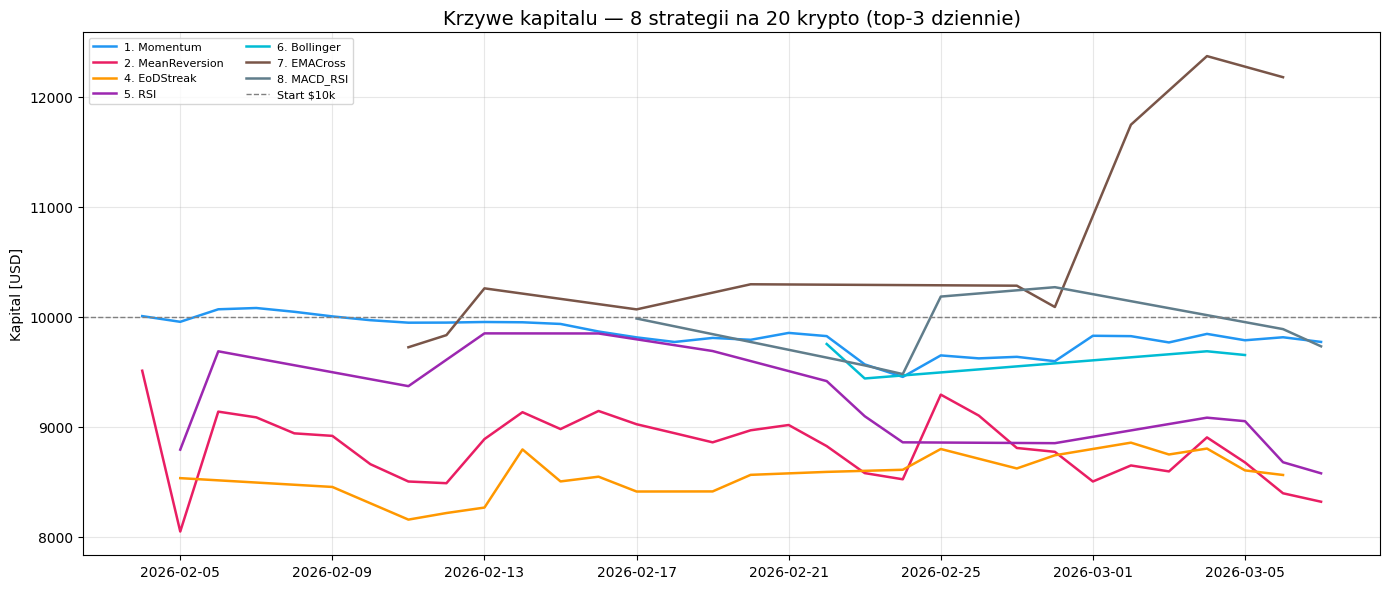

Zapisano: crypto_plot1_equity_curves.png


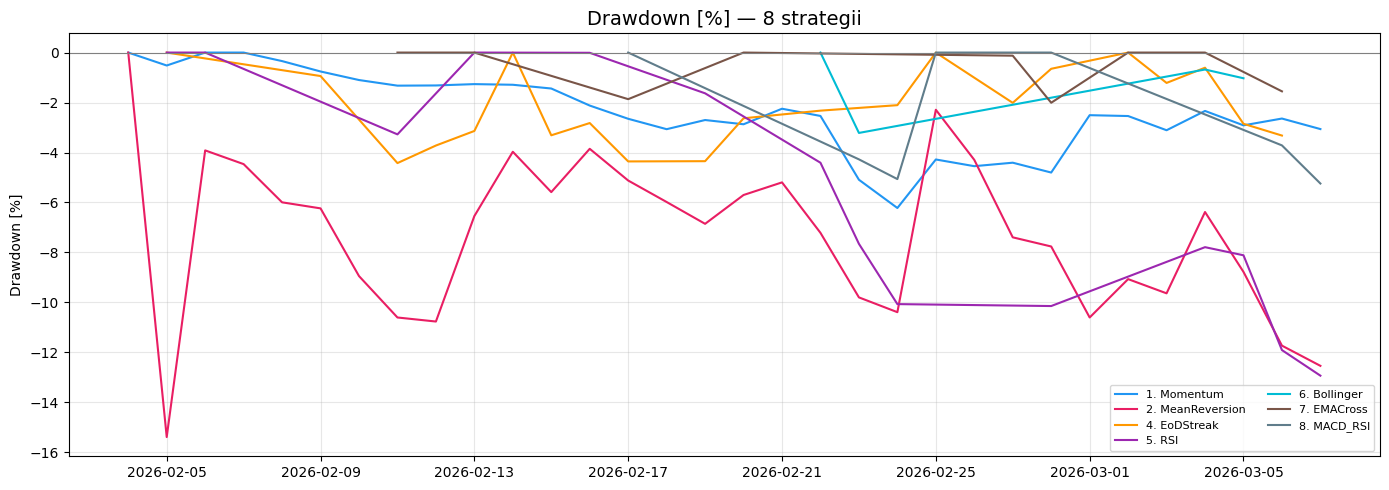

Zapisano: crypto_plot2_drawdown.png


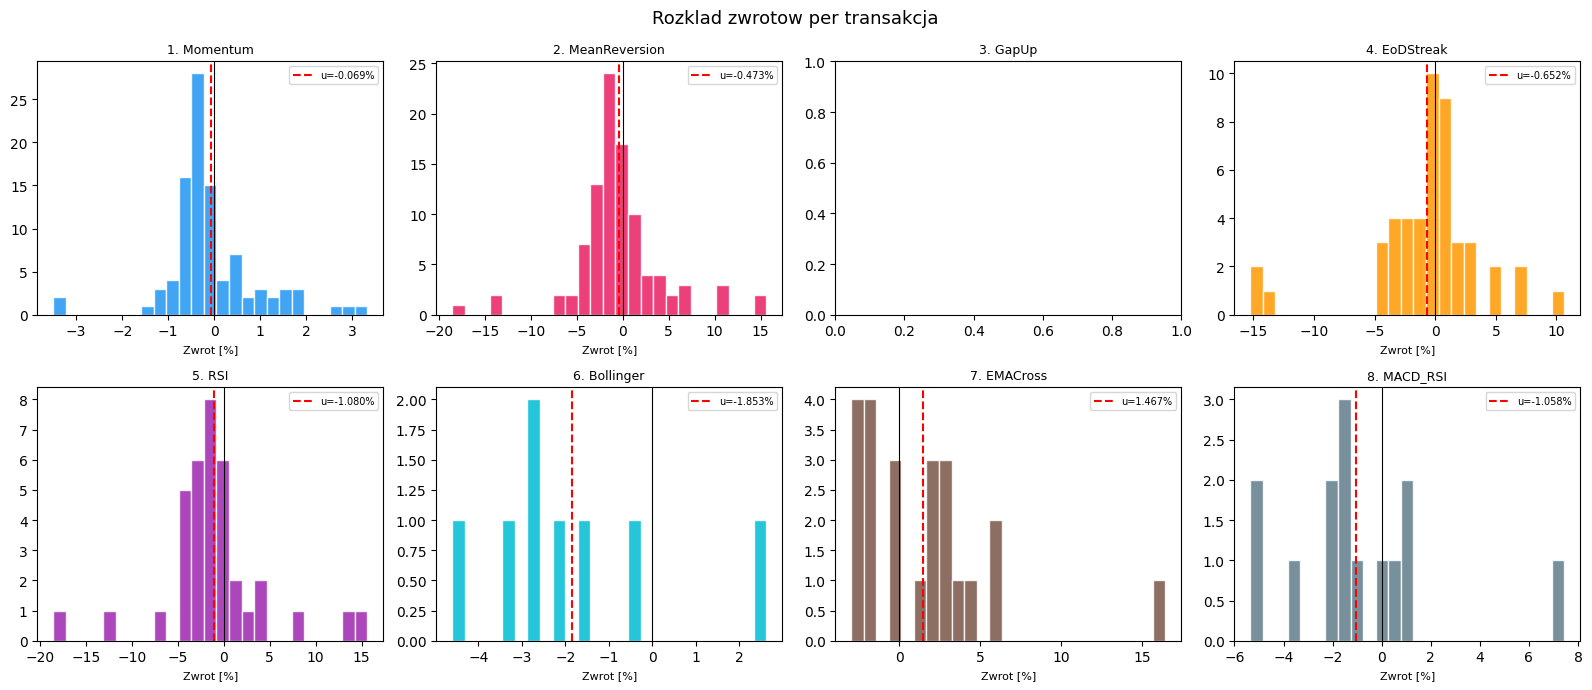

Zapisano: crypto_plot3_distributions.png


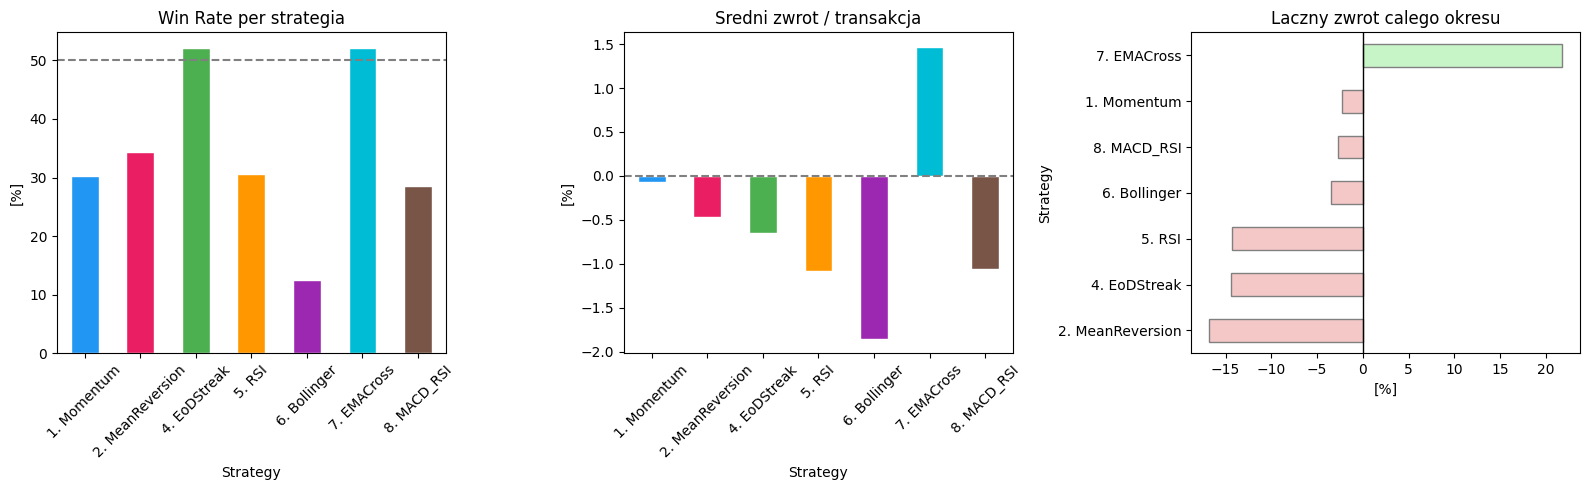

Zapisano: crypto_plot4_win_rate.png


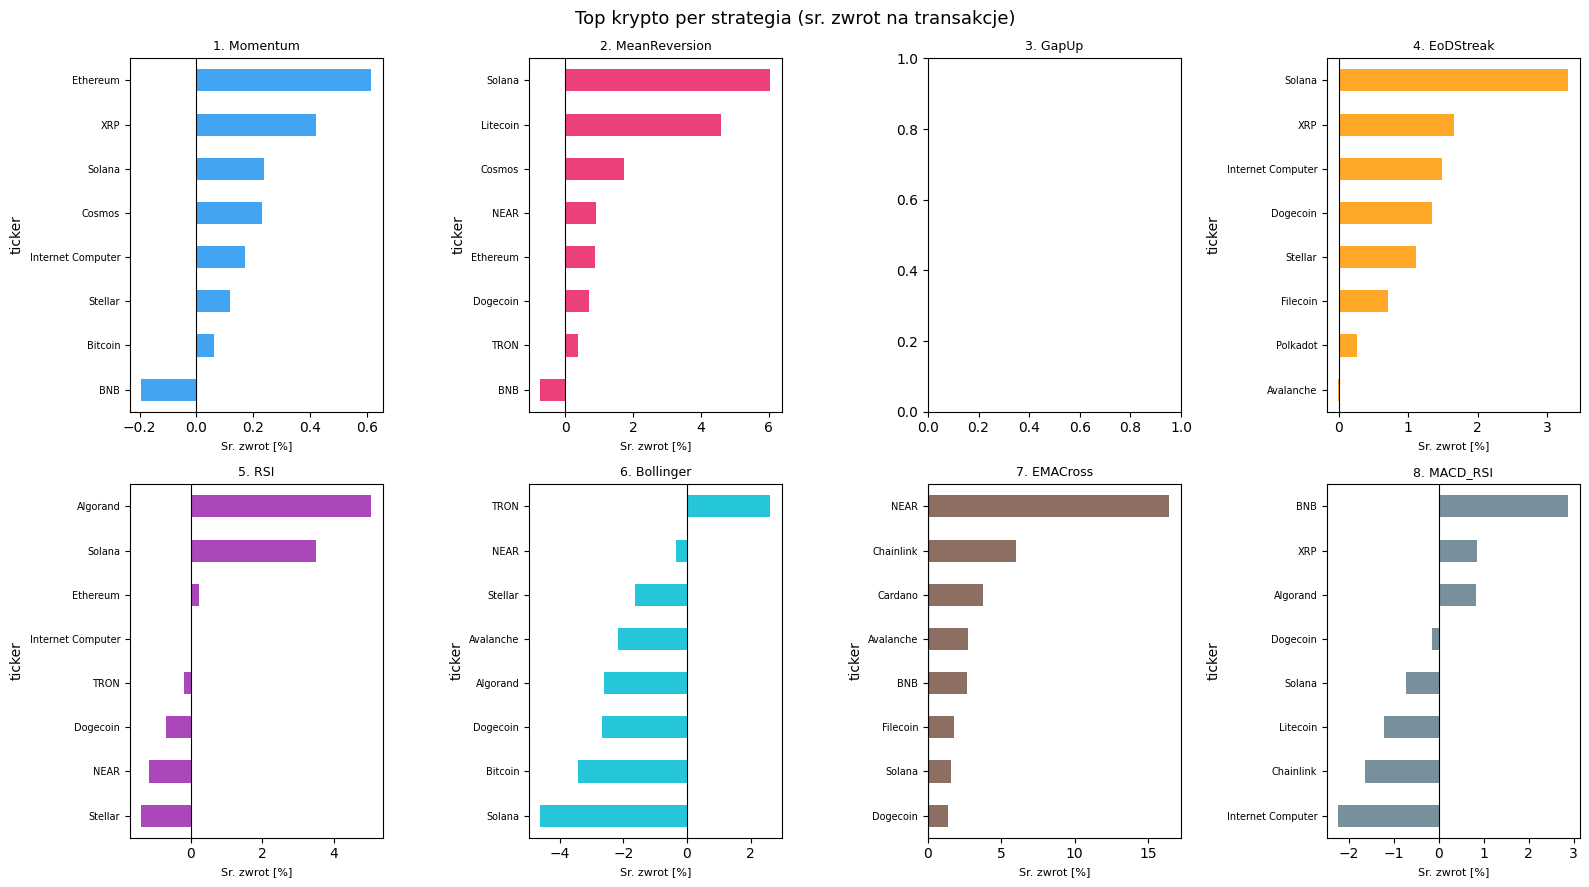

Zapisano: crypto_plot5_top_tickers.png


In [13]:
# ── Wizualizacje ─────────────────────────────────────────────────────────────
PALETTE = ["#2196F3","#E91E63","#4CAF50","#FF9800",
           "#9C27B0","#00BCD4","#795548","#607D8B"]

def max_dd_series(series):
    peak = series.cummax()
    return (series - peak) / peak * 100

# ── Plot 1: Equity curves ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for (name, (_, eq)), col in zip(all_results.items(), PALETTE):
    if not eq.empty:
        ax.plot(eq.index, eq["capital"], label=name, color=col, linewidth=1.8)
ax.axhline(INITIAL_CAPITAL, color="gray", linestyle="--", linewidth=1, label="Start $10k")
ax.set_title("Krzywe kapitalu — 8 strategii na 20 krypto (top-3 dziennie)", fontsize=14)
ax.set_ylabel("Kapital [USD]")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crypto_plot1_equity_curves.png", dpi=150)
plt.show()
print("Zapisano: crypto_plot1_equity_curves.png")

# ── Plot 2: Drawdown ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for (name, (_, eq)), col in zip(all_results.items(), PALETTE):
    if not eq.empty:
        ax.plot(eq.index, max_dd_series(eq["capital"]), label=name, color=col, linewidth=1.5)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Drawdown [%] — 8 strategii", fontsize=14)
ax.set_ylabel("Drawdown [%]")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crypto_plot2_drawdown.png", dpi=150)
plt.show()
print("Zapisano: crypto_plot2_drawdown.png")

# ── Plot 3: Rozklady zwrotow per transakcja (2x4) ─────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, (name, (tr, _)), col in zip(axes, all_results.items(), PALETTE):
    if tr.empty:
        ax.set_title(name, fontsize=9); continue
    ax.hist(tr["net_return"] * 100, bins=25, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    mu = tr["net_return"].mean() * 100
    ax.axvline(mu, color="red", linewidth=1.5, linestyle="--", label=f"u={mu:.3f}%")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Zwrot [%]", fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle("Rozklad zwrotow per transakcja", fontsize=13)
plt.tight_layout()
plt.savefig("crypto_plot3_distributions.png", dpi=150)
plt.show()
print("Zapisano: crypto_plot3_distributions.png")

# ── Plot 4: Win Rate / avg return / total return ───────────────────────────
rows = []
for name, (tr, eq) in all_results.items():
    if tr.empty or eq.empty: continue
    rows.append({
        "Strategy":       name,
        "Win Rate [%]":   (tr["net_return"] > 0).mean() * 100,
        "Avg Return [%]": tr["net_return"].mean() * 100,
        "Total [%]":      (eq["capital"].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100,
    })
sdf = pd.DataFrame(rows).set_index("Strategy")
bar_c = PALETTE[:len(sdf)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sdf["Win Rate [%]"].plot.bar(ax=axes[0], color=bar_c, edgecolor="white")
axes[0].axhline(50, color="gray", linestyle="--")
axes[0].set_title("Win Rate per strategia")
axes[0].set_ylabel("[%]")
axes[0].tick_params(axis="x", rotation=45)

sdf["Avg Return [%]"].plot.bar(ax=axes[1], color=bar_c, edgecolor="white")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Sredni zwrot / transakcja")
axes[1].set_ylabel("[%]")
axes[1].tick_params(axis="x", rotation=45)

st = sdf["Total [%]"].sort_values()
colors_t = ["#c8f5c8" if v >= 0 else "#f5c8c8" for v in st]
st.plot.barh(ax=axes[2], color=colors_t, edgecolor="gray")
axes[2].axvline(0, color="black", linewidth=1)
axes[2].set_title("Laczny zwrot calego okresu")
axes[2].set_xlabel("[%]")
plt.tight_layout()
plt.savefig("crypto_plot4_win_rate.png", dpi=150)
plt.show()
print("Zapisano: crypto_plot4_win_rate.png")

# ── Plot 5: Top krypto per strategia (2x4) ────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
for ax, (name, (tr, _)), col in zip(axes, all_results.items(), PALETTE):
    if tr.empty:
        ax.set_title(name, fontsize=9); continue
    top = tr.groupby("ticker")["net_return"].mean().sort_values().tail(8) * 100
    top.plot.barh(ax=ax, color=col, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Sr. zwrot [%]", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
plt.suptitle("Top krypto per strategia (sr. zwrot na transakcje)", fontsize=13)
plt.tight_layout()
plt.savefig("crypto_plot5_top_tickers.png", dpi=150)
plt.show()
print("Zapisano: crypto_plot5_top_tickers.png")


In [14]:
# ── Trade log — styled DataFrame per strategia ───────────────────────────────
from IPython.display import display

def style_trades(trades_df, strategy_name):
    if trades_df.empty:
        print(f"{strategy_name}: brak transakcji.")
        return
    df = trades_df.copy()
    df["date"]       = df["date"].astype(str)
    df["buy"]        = df["buy"].map("{:.4f}".format)
    df["sell"]       = df["sell"].map("{:.4f}".format)
    df["net_return"] = df["net_return"].map("{:+.4%}".format)
    df["pnl"]        = df["pnl"].map("{:+.2f} USD".format)
    view = df[["date","ticker","buy","sell","net_return","pnl"]]

    def color_ret(val):
        try:
            v = float(val.replace("%","").replace("+",""))
            return f"background-color: {'#c8f5c8' if v > 0 else '#f5c8c8' if v < 0 else ''}"
        except:
            return ""

    styled = (
        view.style
        .set_caption(f"Trade Log — {strategy_name} ({len(view)} transakcji)")
        .applymap(color_ret, subset=["net_return","pnl"])
        .set_table_styles([
            {"selector":"caption","props":[("font-size","14px"),("font-weight","bold")]},
            {"selector":"th","props":[("background-color","#2c3e50"),("color","white"),("font-size","11px")]},
            {"selector":"td","props":[("font-size","11px"),("padding","3px 8px")]},
        ])
        .hide(axis="index")
    )
    return styled

for name, (tr, _) in all_results.items():
    display(style_trades(tr, name))
    print()


C:\Users\szymo\AppData\Local\Temp\ipykernel_23948\283363659.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_ret, subset=["net_return","pnl"])


date,ticker,buy,sell,net_return,pnl
2026-02-04,Cardano,0.2942,0.2946,-0.0672%,-2.24 USD
2026-02-04,Cosmos,2.0497,2.0629,+0.4436%,+14.79 USD
2026-02-04,Filecoin,1.0752,1.0751,-0.2104%,-7.01 USD
2026-02-05,Cosmos,2.0031,1.9887,-0.9203%,-30.69 USD
2026-02-05,Litecoin,58.9968,58.8812,-0.3959%,-13.20 USD
2026-02-05,Avalanche,9.7272,9.7236,-0.2378%,-7.93 USD
2026-02-06,Ethereum,1869.2325,1901.3408,+1.5177%,+50.36 USD
2026-02-06,Stellar,0.1507,0.1510,-0.0173%,-0.57 USD
2026-02-06,Bitcoin,63448.3164,64803.5352,+1.9359%,+64.23 USD
2026-02-07,Cosmos,1.9860,1.9906,+0.0302%,+1.01 USD


C:\Users\szymo\AppData\Local\Temp\ipykernel_23948\283363659.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_ret, subset=["net_return","pnl"])


date,ticker,buy,sell,net_return,pnl
2026-02-04,Algorand,0.1058,0.1029,-2.9031%,-96.77 USD
2026-02-04,XRP,1.5760,1.5105,-4.3598%,-145.33 USD
2026-02-04,BNB,753.9329,699.0833,-7.4751%,-249.17 USD
2026-02-05,XRP,1.4879,1.2139,-18.6143%,-589.99 USD
2026-02-05,Stellar,0.1702,0.1468,-13.9537%,-442.27 USD
2026-02-05,Bitcoin,72716.1641,62978.6836,-13.5911%,-430.78 USD
2026-02-06,Solana,75.5126,87.4650,+15.6284%,+419.14 USD
2026-02-06,NEAR,0.9483,1.0868,+14.4054%,+386.34 USD
2026-02-06,Litecoin,49.6788,55.0627,+10.6375%,+285.29 USD
2026-02-07,Cardano,0.2732,0.2724,-0.5128%,-15.62 USD



3. GapUp: brak transakcji.


...

date,ticker,buy,sell,net_return,pnl
2026-02-22,Dogecoin,0.0979,0.0955,-2.6606%,-88.69 USD
2026-02-22,Algorand,0.0890,0.0868,-2.6202%,-87.34 USD
2026-02-22,Avalanche,9.0483,8.8707,-2.1629%,-72.10 USD
2026-02-23,Bitcoin,66720.8750,64567.2891,-3.4278%,-111.42 USD
2026-02-23,Solana,81.2732,77.6953,-4.6023%,-149.60 USD
2026-02-23,Stellar,0.1535,0.1513,-1.6193%,-52.64 USD
2026-03-04,TRON,0.2792,0.2871,+2.6220%,+247.47 USD
2026-03-05,NEAR,1.2771,1.2751,-0.3521%,-34.10 USD


C:\Users\szymo\AppData\Local\Temp\ipykernel_23948\283363659.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_ret, subset=["net_return","pnl"])


date,ticker,buy,sell,net_return,pnl
2026-02-11,Stellar,0.1587,0.1545,-2.8462%,-142.31 USD
2026-02-11,Internet Computer,2.3914,2.3314,-2.7077%,-135.39 USD
2026-02-12,Filecoin,0.8916,0.9127,+2.1705%,+70.34 USD
2026-02-12,Stellar,0.1561,0.1563,-0.1085%,-3.52 USD
2026-02-12,Dogecoin,0.0916,0.0930,+1.3435%,+43.54 USD
2026-02-13,Avalanche,8.8481,9.1484,+3.1936%,+104.67 USD
2026-02-13,Cardano,0.2624,0.2727,+3.7320%,+122.32 USD
2026-02-13,Filecoin,0.9025,0.9590,+6.0570%,+198.52 USD
2026-02-17,Solana,86.6079,85.1990,-1.8268%,-62.47 USD
2026-02-17,Internet Computer,2.4158,2.3812,-1.6301%,-55.74 USD


C:\Users\szymo\AppData\Local\Temp\ipykernel_23948\283363659.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_ret, subset=["net_return","pnl"])


date,ticker,buy,sell,net_return,pnl
2026-02-17,Dogecoin,0.1006,0.1006,-0.1638%,-16.38 USD
2026-02-23,Avalanche,8.8118,8.3566,-5.3656%,-178.56 USD
2026-02-23,Internet Computer,2.1288,2.0855,-2.2379%,-74.47 USD
2026-02-23,Cosmos,2.2287,2.1168,-5.2179%,-173.65 USD
2026-02-24,Solana,78.4065,79.0351,+0.6018%,+19.17 USD
2026-02-24,Litecoin,51.7969,51.1600,-1.4296%,-45.54 USD
2026-02-24,Chainlink,8.3232,8.2027,-1.6473%,-52.48 USD
2026-02-25,BNB,584.4485,629.1083,+7.4414%,+705.30 USD
2026-02-28,XRP,1.3624,1.3769,+0.8592%,+43.75 USD
2026-02-28,Algorand,0.0871,0.0879,+0.8171%,+41.61 USD


In [15]:
# ── Print Summary — copy-paste do artykulu / skryptu ─────────────────────────
print("=" * 66)
print("  CRYPTO INTRADAY STRATEGIES — PODSUMOWANIE")
print("=" * 66)

for strat_name, (tr, eq) in all_results.items():
    print(f"\n{'─'*66}")
    print(f"  Strategia: {strat_name}")
    print(f"{'─'*66}")
    if tr.empty or eq.empty:
        print("  Brak transakcji.")
        continue

    final     = eq["capital"].iloc[-1]
    total_ret = (final - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    win_rate  = (tr["net_return"] > 0).mean() * 100
    avg_ret   = tr["net_return"].mean() * 100
    best      = tr["net_return"].max()  * 100
    worst     = tr["net_return"].min()  * 100
    peak      = eq["capital"].cummax()
    max_dd    = ((eq["capital"] - peak) / peak * 100).min()
    daily     = tr.groupby("date")["pnl"].sum()
    sharpe    = daily.mean() / daily.std() * np.sqrt(365) if daily.std() > 0 else 0.0

    print(f"  Kapital startowy :  {INITIAL_CAPITAL:>12,.0f} USD")
    print(f"  Kapital koncowy  :  {final:>12,.0f} USD")
    print(f"  Zwrot calkowity  :  {total_ret:>11.2f} %")
    print(f"  Max Drawdown     :  {max_dd:>11.2f} %")
    print(f"  Sharpe (annul.)  :  {sharpe:>11.2f}")
    print(f"  Liczba transakcji:  {len(tr):>12}")
    print(f"  Win Rate         :  {win_rate:>11.1f} %")
    print(f"  Sr. zwrot/trans. :  {avg_ret:>11.4f} %")
    print(f"  Najlepsza trans. :  {best:>11.4f} %")
    print(f"  Najgorsza trans. :  {worst:>11.4f} %")

    top5 = tr.groupby("ticker")["net_return"].mean().sort_values(ascending=False).head(5)
    print(f"\n  Top-5 krypto (sr. zwrot):")
    for ticker, r in top5.items():
        print(f"    {ticker:<25} {r*100:+.4f}%")

print("\n" + "=" * 66)
print("  Wykresy zapisane:")
for i, f in enumerate([
    "crypto_plot1_equity_curves.png",
    "crypto_plot2_drawdown.png",
    "crypto_plot3_distributions.png",
    "crypto_plot4_win_rate.png",
    "crypto_plot5_top_tickers.png",
], 1):
    print(f"    [{i}] {f}")
print("=" * 66)


  CRYPTO INTRADAY STRATEGIES — PODSUMOWANIE

──────────────────────────────────────────────────────────────────
  Strategia: 1. Momentum
──────────────────────────────────────────────────────────────────
  Kapital startowy :        10,000 USD
  Kapital koncowy  :         9,771 USD
  Zwrot calkowity  :        -2.29 %
  Max Drawdown     :        -6.22 %
  Sharpe (annul.)  :        -1.61
  Liczba transakcji:            96
  Win Rate         :         30.2 %
  Sr. zwrot/trans. :      -0.0688 %
  Najlepsza trans. :       3.3237 %
  Najgorsza trans. :      -3.5025 %

  Top-5 krypto (sr. zwrot):
    Ethereum                  +0.6163%
    XRP                       +0.4199%
    Solana                    +0.2369%
    Cosmos                    +0.2299%
    Internet Computer         +0.1706%

──────────────────────────────────────────────────────────────────
  Strategia: 2. MeanReversion
──────────────────────────────────────────────────────────────────
  Kapital startowy :        10,000 USD
  Kap